# Rigidité oculaire (méthode de Hilbert) — corrélations avec les mesures ophtalmiques

Visualisation de la rigidité oculaire calculée par la **méthode de Hilbert**
(colonnes `_full_hilbert` de `rigidity_full_pipeline.csv`, produite par
`compute_rigidity_full_pipeline.py`), croisée avec les mesures ophtalmiques
cliniques (`sansori_db.db`, table `Measurements`).

Fonctions et constantes partagées reprises de `visualize_rigidity.ipynb`
(identifiants, unités, graphique apparié avant/après, test de Wilcoxon,
couleurs de phase), puis :

1. **Chargement des données** — rigidité (Hilbert) + mesures ophtalmiques.
2. **Boxplots avant/après vol** — rigidité : `CT`, `delta_CT`, `k`.
3. **Boxplots avant/après vol** — mesures ophtalmiques : `TRT250` (I/S/N/T),
   `IOP`, `OPA`, `AL`.
4. **Influence des paramètres sur `k`** — `IOP`, `OPA`, `CT`, `delta_CT`, `AL`
   (corrélations de Spearman et de Pearson).
5. **Corrélation (Spearman + Pearson) des changements** —
   `log2(k après / k avant)` vs le changement des mesures ophtalmiques
   (`FC = log2(après/avant)` pour `IOP`/`OPA`/`AL`, delta (après − avant)
   pour `TRT250`).
6. **Valeurs avant vol (Hilbert) vs delta TRT250** — `CT`, `delta_CT` et `k`
   *avant vol* comparés au changement (après − avant) de chaque quadrant
   `TRT250`.


In [1]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, spearmanr, pearsonr


def parse_patient(s):
    # '01_210713001' -> '01'
    return str(s).split("_")[0]


def parse_phase(s):
    s = str(s).lower()
    if "before" in s:
        return "before"
    if "post" in s:
        return "post"
    return np.nan


def parse_eye_replicate(s):
    # '...rigidity_OD' -> ('OD', <NA>) ; '...rigidity_OS4' -> ('OS', 4)
    tail = str(s).split("_")[-1]
    m = re.match(r"(OD|OS)(\d?)", tail, flags=re.IGNORECASE)
    if not m:
        return np.nan, pd.NA
    eye = m.group(1).upper()
    rep = int(m.group(2)) if m.group(2) else pd.NA
    return eye, rep


UNITS = {"k": "mm⁻³", "delta_V": "mm³", "delta_CT": "mm", "CT": "mm",
         "delta_CT_over_CT": "", "hr": "BPM", "AL": "mm", "IOP": "mmHg", "OPA": "mmHg",
         "TRT250_I": "µm", "TRT250_S": "µm",
         "TRT250_N": "µm", "TRT250_T": "µm"}


def pretty(metric):
    """Display name for a metric: 'delta_' -> 'Δ', '_over_' -> '/'."""
    return metric.replace("delta_", "Δ").replace("_over_", "/")


def unit_suffix(metric):
    """' (unit)', or '' if no unit is defined for this metric."""
    unit = UNITS.get(metric, "")
    return f" ({unit})" if unit else ""


In [2]:
EYE_COLORS = {"OD": "#1f77b4", "OS": "#d62728"}
X_BEFORE, X_POST = 1.0, 2.0          # positions des boxplots
X_PTS_BEFORE, X_PTS_POST = 1.30, 1.70  # positions des points/lignes (entre les box)

def paired_before_after(agg, metric, ax=None):
    """Boxplots avant/après + points individuels + lignes appariées (par œil)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    piv = agg.pivot_table(index=["patient_id", "eye"], columns="phase",
                          values=metric, observed=True)
    for c in ["before", "post"]:
        if c not in piv.columns:
            piv[c] = np.nan
    piv = piv[["before", "post"]]

    before = piv["before"].values.astype(float)
    post = piv["post"].values.astype(float)

    # --- boxplots ---
    bp = ax.boxplot([before[np.isfinite(before)], post[np.isfinite(post)]],
                    positions=[X_BEFORE, X_POST], widths=0.45,
                    showfliers=False, patch_artist=True,
                    medianprops=dict(color="black", lw=1.5))
    for patch in bp["boxes"]:
        patch.set(facecolor="0.93", edgecolor="0.5")

    # --- points + lignes appariées ---
    seen = set()
    for (pid, eye), row in piv.iterrows():
        b, p = row["before"], row["post"]
        col = EYE_COLORS.get(eye, "gray")
        if np.isfinite(b) and np.isfinite(p):
            ax.plot([X_PTS_BEFORE, X_PTS_POST], [b, p],
                    color="0.75", lw=0.8, zorder=1)
        if np.isfinite(b):
            ax.scatter(X_PTS_BEFORE, b, color=col, s=28, zorder=2,
                       label=(eye if eye not in seen else None))
            seen.add(eye)
        if np.isfinite(p):
            ax.scatter(X_PTS_POST, p, color=col, s=28, zorder=2,
                       label=(eye if eye not in seen else None))
            seen.add(eye)

    n_pairs = int((np.isfinite(before) & np.isfinite(post)).sum())
    ax.set_xticks([X_BEFORE, X_POST])
    ax.set_xticklabels(["Before", "After"])
    ax.set_xlim(0.5, 2.5)
    ax.set_ylabel(f"{pretty(metric)}{unit_suffix(metric)}")
    ax.set_title(f"{pretty(metric)}: before vs after flight")
    ax.legend(title=f"eye (pairs = {n_pairs})", fontsize=8)
    return ax


def paired_test(agg, metric):
    piv = agg.pivot_table(index=["patient_id", "eye"], columns="phase",
                          values=metric, observed=True)
    if not {"before", "post"} <= set(piv.columns):
        return dict(metric=metric, n=0, delta_median=np.nan, p=np.nan)
    paired = piv.dropna(subset=["before", "post"])
    if len(paired) < 3:
        return dict(metric=metric, n=len(paired), delta_median=np.nan, p=np.nan)
    _, p = wilcoxon(paired["before"], paired["post"])
    return dict(metric=metric, n=len(paired),
                delta_median=float(np.median(paired["post"] - paired["before"])),
                p=float(p))


PHASE_COLORS = {"before": "#1f77b4", "post": "#d62728"}
PHASE_LABELS = {"before": "before", "post": "after"}


# 1. Chargement des données

`rigidity_full_pipeline.csv` pour la rigidité (méthode de **Hilbert**,
colonnes `_full_hilbert`) et les mesures cliniques déjà jointes par le
pipeline (`hr`, `AL`, `IOP`, `OPA`) ; la base `sansori_db.db` (table
`Measurements`) pour les mesures `TRT250` (épaisseur rétinienne totale à
250 µm de la fovéa, quadrants Inférieur/Supérieur/Nasal/Temporal), absentes
du pipeline. Les fonctions de jointure clinique (`load_clinical_db`,
`lookup_clinical`, `astro_code_from_folder`, `parse_moment`) sont reprises
telles quelles de `compute_rigidity_time_series.py` — même logique que
celle déjà utilisée pour joindre `AL` (biométrie) dans le pipeline.


In [3]:
# --- 1.1 Rigidité (méthode de Hilbert) ---
CSV_PATH = Path("E:/SANSORI/rigidity_full_pipeline.csv")

df = pd.read_csv(CSV_PATH)
df = df.rename(columns={
    "CT_full_hilbert": "CT",
    "delta_CT_full_hilbert": "delta_CT",
    "delta_V_full_hilbert": "delta_V",
    "k_full_hilbert": "k",
})[["patient", "moment", "condition", "hr", "AL", "IOP", "OPA",
    "CT", "delta_CT", "delta_V", "k"]]

df["patient_id"] = df["patient"].map(parse_patient)
df["phase"] = df["moment"].map(parse_phase)
_eye_rep = df["condition"].map(parse_eye_replicate)
df["eye"] = [er[0] for er in _eye_rep]
df["replicate"] = [er[1] for er in _eye_rep]
df["phase"] = pd.Categorical(df["phase"], categories=["before", "post"], ordered=True)

print(f"{len(df)} lignes chargées")
df.head()


106 lignes chargées


,patient,moment,condition,hr,AL,IOP,OPA,CT,delta_CT,delta_V,k,patient_id,phase,eye,replicate
0,01_210713001,210713001before_rigidity,210713001before_rigidity_OD,63.0,23.15,17.7,2.6,0.2691,0.004100,2.682836,0.051086,01,before,OD,<NA>
1,01_210713001,210713001before_rigidity,210713001before_rigidity_OS1,63.0,23.11,15.9,2.5,0.2613,0.009520,6.203102,0.023542,01,before,OS,1
2,01_210713001,210713001before_rigidity,210713001before_rigidity_OS2,63.0,23.11,15.9,2.5,0.2730,0.007702,5.023990,0.029067,01,before,OS,2
3,01_210713001,210713001post_rigidity,210713001post_rigidity_OD1,67.0,23.04,12.9,1.7,0.3081,0.012144,7.902258,0.015666,01,post,OD,1
4,01_210713001,210713001post_rigidity,210713001post_rigidity_OD2,67.0,23.04,12.9,1.7,0.2574,0.011244,7.280114,0.017004,01,post,OD,2


In [4]:
# --- 1.2 Mesures ophtalmiques (TRT250) depuis sansori_db.db ---
# Astronauts/ (gitignored, hors du package) n'est pas sur sys.path par défaut ici
# comme il l'est quand compute_rigidity_full_pipeline.py est lancé directement.
sys.path.insert(0, str(Path("../Astronauts").resolve()))

import matplotlib
matplotlib.use("Agg")  # compute_rigidity_time_series bascule le backend au chargement
from compute_rigidity_time_series import (
    load_clinical_db, lookup_clinical, astro_code_from_folder, parse_moment,
)
%matplotlib inline

DB_PATH = Path("E:/SANSORI/sansori_db.db")
TRT_DESCRIPTIONS = ["TRT250_I", "TRT250_S", "TRT250_N", "TRT250_T"]

meas, id2code = load_clinical_db(DB_PATH)

_code = df["patient"].map(lambda p: astro_code_from_folder(p, id2code))
_moment_db = df["moment"].map(parse_moment)  # 'before'/'after' (vs. phase 'before'/'post')

for desc in TRT_DESCRIPTIONS:
    df[desc] = [
        lookup_clinical(meas, code, eye, moment, desc)
        for code, eye, moment in zip(_code, df["eye"], _moment_db)
    ]

df[["patient_id", "phase", "eye"] + TRT_DESCRIPTIONS].head(10)


c:\Users\transformer\anaconda3\envs\pyOR\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,patient_id,phase,eye,TRT250_I,TRT250_S,TRT250_N,TRT250_T
0,01,before,OD,433.0,461.0,394.5,340.5
1,01,before,OS,424.0,460.0,420.5,348.0
2,01,before,OS,424.0,460.0,420.5,348.0
3,01,post,OD,458.0,477.0,411.0,345.0
4,01,post,OD,458.0,477.0,411.0,345.0
5,01,post,OS,437.0,473.0,437.0,345.0
6,01,post,OS,437.0,473.0,437.0,345.0
7,02,before,OD,388.5,406.0,380.0,326.5
8,02,before,OS,420.0,434.0,392.0,323.5
9,02,post,OD,397.0,417.0,401.0,327.0


In [5]:
# --- 1.3 Agrégation des réplicats (mean par patient/œil/phase) ---
df["delta_CT_over_CT"] = df["delta_CT"] / df["CT"]  # amplitude pulsatile relative (sans unité)

METRICS_RIGIDITY = ["CT", "delta_CT", "k", "delta_CT_over_CT"]
METRICS_OPHTALMIC = TRT_DESCRIPTIONS + ["IOP", "OPA", "AL"]
NUM_COLS = METRICS_RIGIDITY + METRICS_OPHTALMIC + ["hr"]

agg = (df.groupby(["patient_id", "eye", "phase"], observed=True)[NUM_COLS]
         .mean()
         .reset_index())
print(f"{len(agg)} échantillons agrégés")
agg.head()


54 échantillons agrégés


,patient_id,eye,phase,CT,delta_CT,k,delta_CT_over_CT,TRT250_I,TRT250_S,TRT250_N,TRT250_T,IOP,OPA,AL,hr
0,01,OD,before,0.26910,0.004100,0.051086,0.015237,433.0,461.0,394.5,340.5,17.7,2.6,23.15,63.0
1,01,OD,post,0.28275,0.011694,0.016335,0.041551,458.0,477.0,411.0,345.0,12.9,1.7,23.04,67.0
2,01,OS,before,0.26715,0.008611,0.026304,0.032322,424.0,460.0,420.5,348.0,15.9,2.5,23.11,63.0
3,01,OS,post,0.26715,0.012244,0.019506,0.047355,437.0,473.0,437.0,345.0,14.3,2.1,22.96,64.5
4,02,OD,before,0.15210,0.004288,0.056769,0.028194,388.5,406.0,380.0,326.5,18.0,3.8,25.55,42.0


# 2. Boxplots avant/après vol — rigidité (méthode de Hilbert)

`CT`, `delta_CT` et `k`, calculés par la méthode de Hilbert (passe-bande
Butterworth + enveloppe de Hilbert, toute la vidéo). Même fonction
`paired_before_after` que `visualize_rigidity.ipynb` (boxplot + points/lignes
appariées par œil), suivie du test apparié de Wilcoxon.


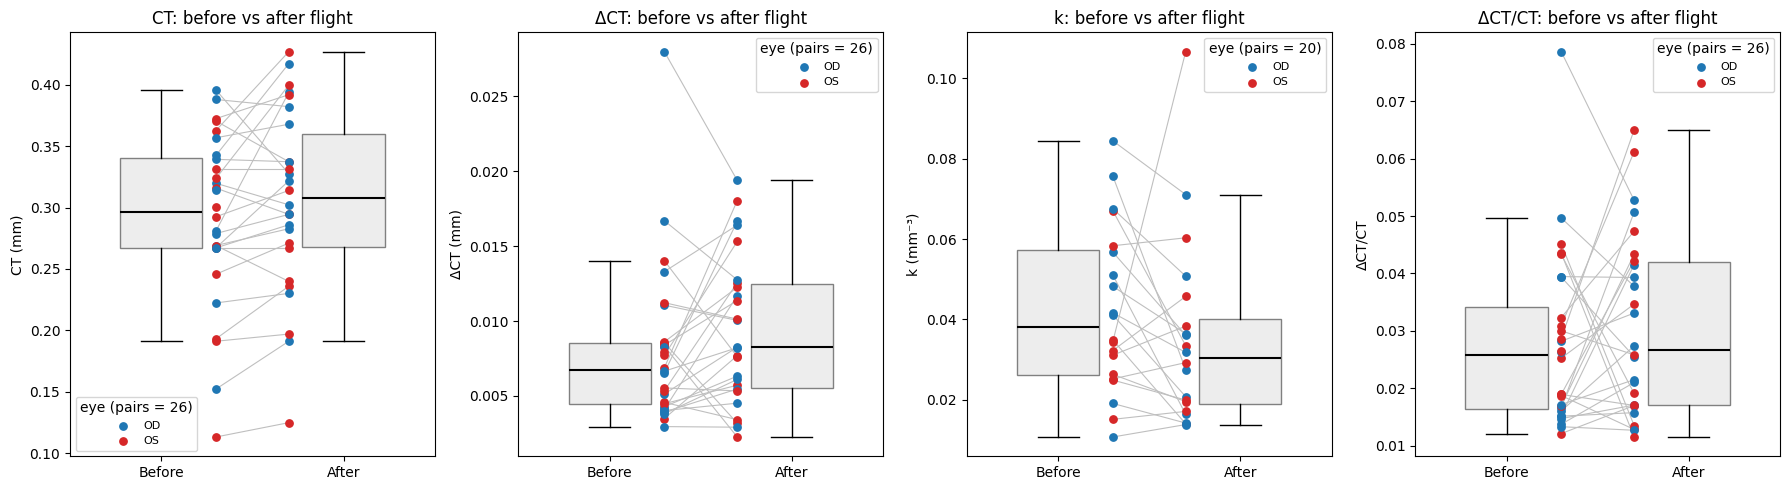

In [6]:
fig, axes = plt.subplots(1, len(METRICS_RIGIDITY), figsize=(4.5 * len(METRICS_RIGIDITY), 5))
for ax, metric in zip(axes, METRICS_RIGIDITY):
    paired_before_after(agg, metric, ax=ax)
fig.tight_layout()
plt.show()


In [7]:
wilcoxon_rigidity = (pd.DataFrame([paired_test(agg, metric) for metric in METRICS_RIGIDITY])
                    .set_index("metric"))
wilcoxon_rigidity


,n,delta_median,p
metric,,,
CT,26,0.012675,0.033410
delta_CT,26,0.001552,0.129101
k,20,-0.008333,0.039989
delta_CT_over_CT,26,0.003345,0.340331


# 3. Boxplots avant/après vol — mesures ophtalmiques

`TRT250_I/S/N/T` (`sansori_db.db`), `IOP` et `OPA` (`visit_data.csv`, déjà
jointes dans le pipeline) et `AL` (`sansori_db.db`, description `Biometry`).


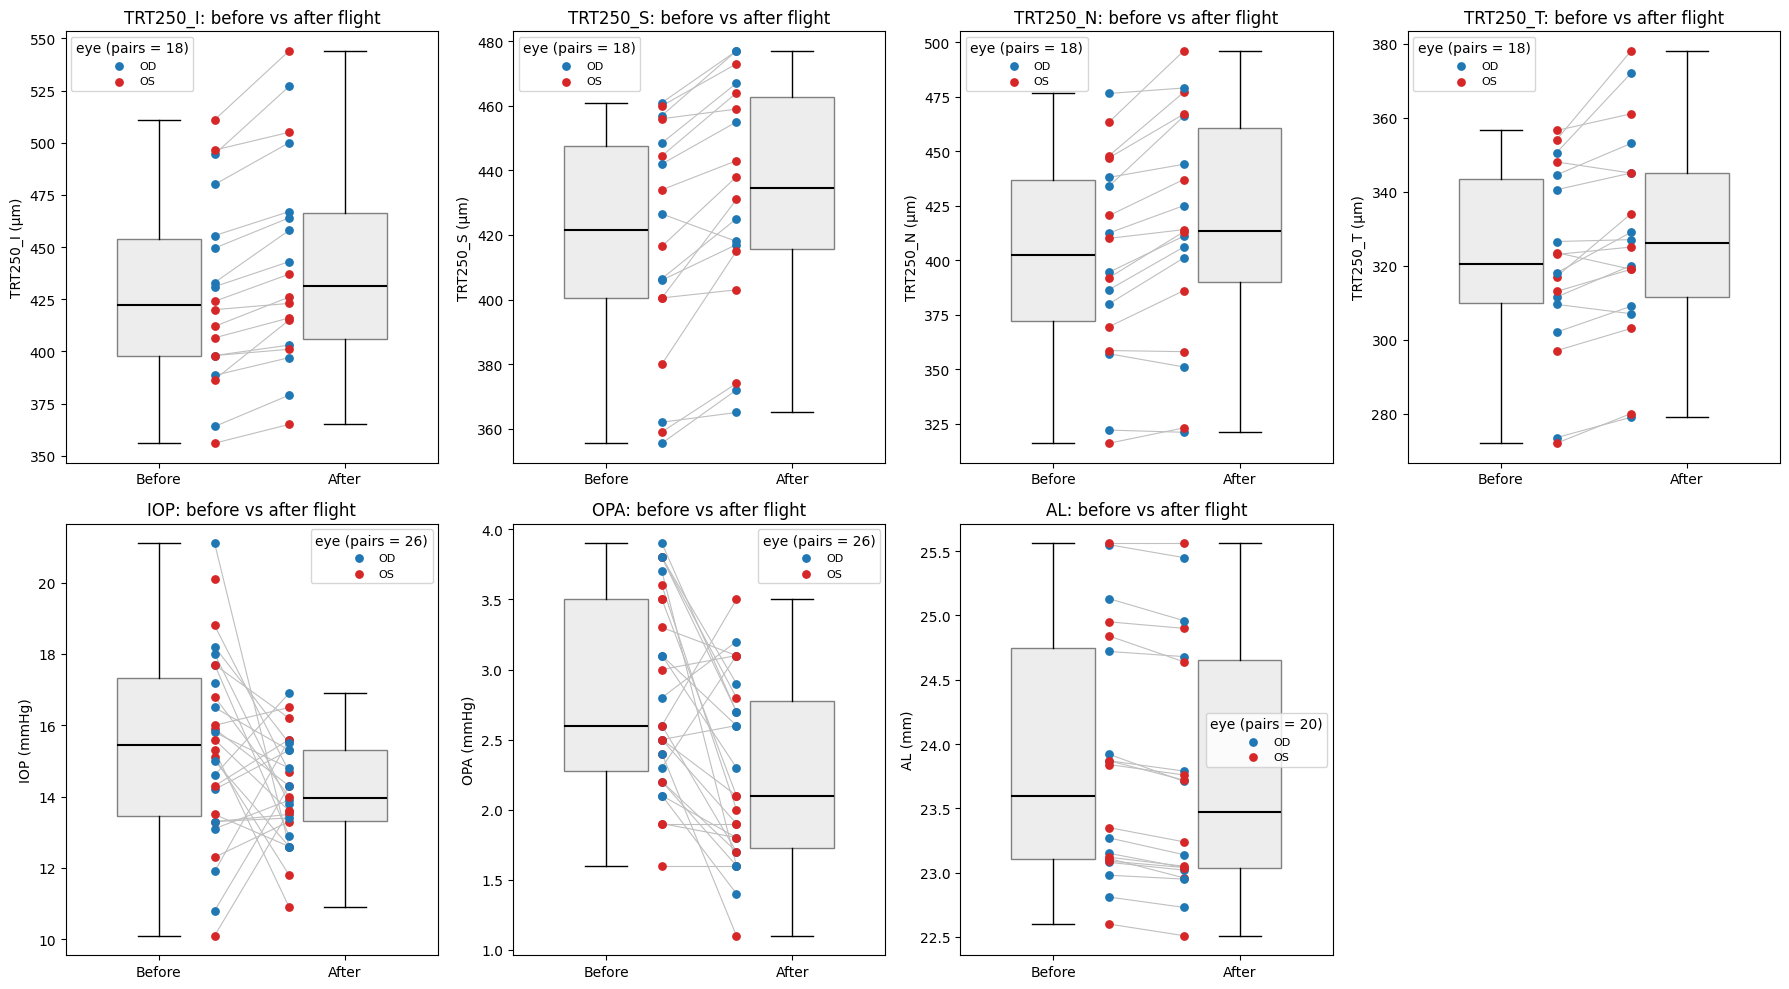

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(4.5 * 4, 5 * 2))
for ax, metric in zip(axes.ravel(), METRICS_OPHTALMIC):
    paired_before_after(agg, metric, ax=ax)
for ax in axes.ravel()[len(METRICS_OPHTALMIC):]:
    ax.axis("off")
fig.tight_layout()
plt.show()


In [9]:
wilcoxon_ophtalmic = (pd.DataFrame([paired_test(agg, metric) for metric in METRICS_OPHTALMIC])
                     .set_index("metric"))
wilcoxon_ophtalmic


,n,delta_median,p
metric,,,
TRT250_I,18,12.500,0.000196
TRT250_S,18,15.500,0.000384
TRT250_N,18,16.500,0.000791
TRT250_T,18,6.000,0.001580
IOP,26,-1.100,0.088793
OPA,26,-0.550,0.001840
AL,20,-0.085,0.000131


# 4. Influence des paramètres sur `k`

Nuages de points `k` (méthode de Hilbert) en fonction de `IOP`, `OPA`, `CT`,
`delta_CT` et `AL` — toutes conditions confondues (avant + après), colorées
par phase, avec les coefficients de corrélation de Spearman et de Pearson
entre le paramètre et `k`.


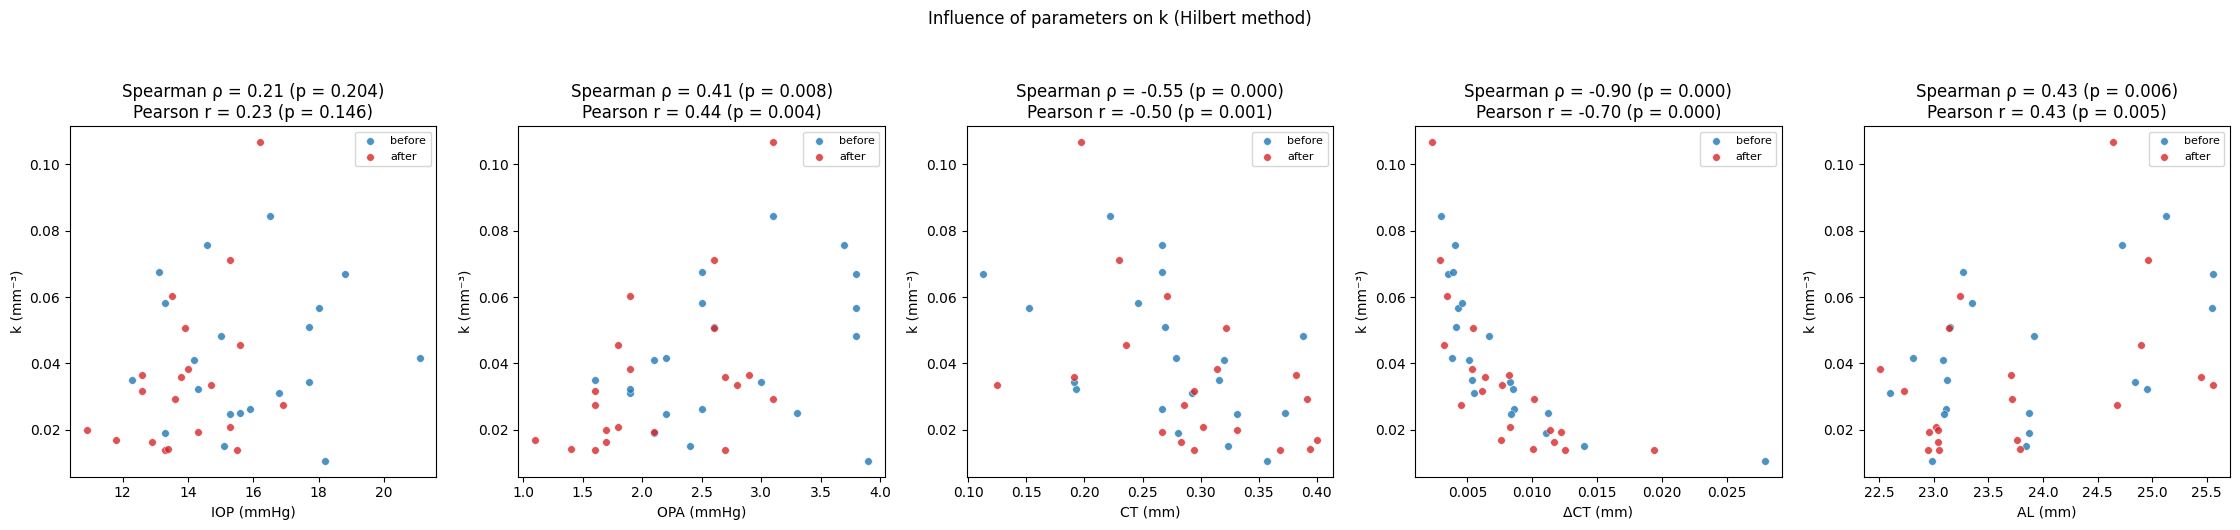

In [10]:
PARAMS_K = ["IOP", "OPA", "CT", "delta_CT", "AL"]

fig, axes = plt.subplots(1, len(PARAMS_K), figsize=(4.5 * len(PARAMS_K), 5))
for ax, param in zip(axes, PARAMS_K):
    d = agg[[param, "k", "phase"]].dropna()
    r_s, p_s = spearmanr(d[param], d["k"])
    r_p, p_p = pearsonr(d[param], d["k"])

    for phase, color in PHASE_COLORS.items():
        dd = d[d["phase"] == phase]
        ax.scatter(dd[param], dd["k"], color=color, s=30, alpha=0.8,
                  edgecolor="white", linewidth=0.4, label=PHASE_LABELS[phase])

    ax.set_xlabel(f"{pretty(param)}{unit_suffix(param)}")
    ax.set_ylabel(f"k{unit_suffix('k')}")
    ax.set_title(f"Spearman ρ = {r_s:.2f} (p = {p_s:.3f})\n"
                 f"Pearson r = {r_p:.2f} (p = {p_p:.3f})")
    ax.legend(fontsize=8)

fig.suptitle("Influence of parameters on k (Hilbert method)", y=1.05)
fig.tight_layout()
plt.show()


# 5. Corrélation (Spearman + Pearson) — changement de `k` vs mesures ophtalmiques

Changement par (patient, œil) : `FC = log2(après / avant)` pour `IOP`, `OPA`
et `AL` ; pour `TRT250` (I/S/N/T), `delta = après − avant` (µm) plutôt qu'un
fold change, une épaisseur rétinienne se comparant plus naturellement en
différence absolue qu'en ratio. Corrélations de Spearman et de Pearson
entre `FC(k)` (méthode de Hilbert) et le changement de chaque mesure
ophtalmique — répond à la question : un changement de rigidité
s'accompagne-t-il d'un changement de même ampleur (et de même signe) de la
mesure ophtalmique ?


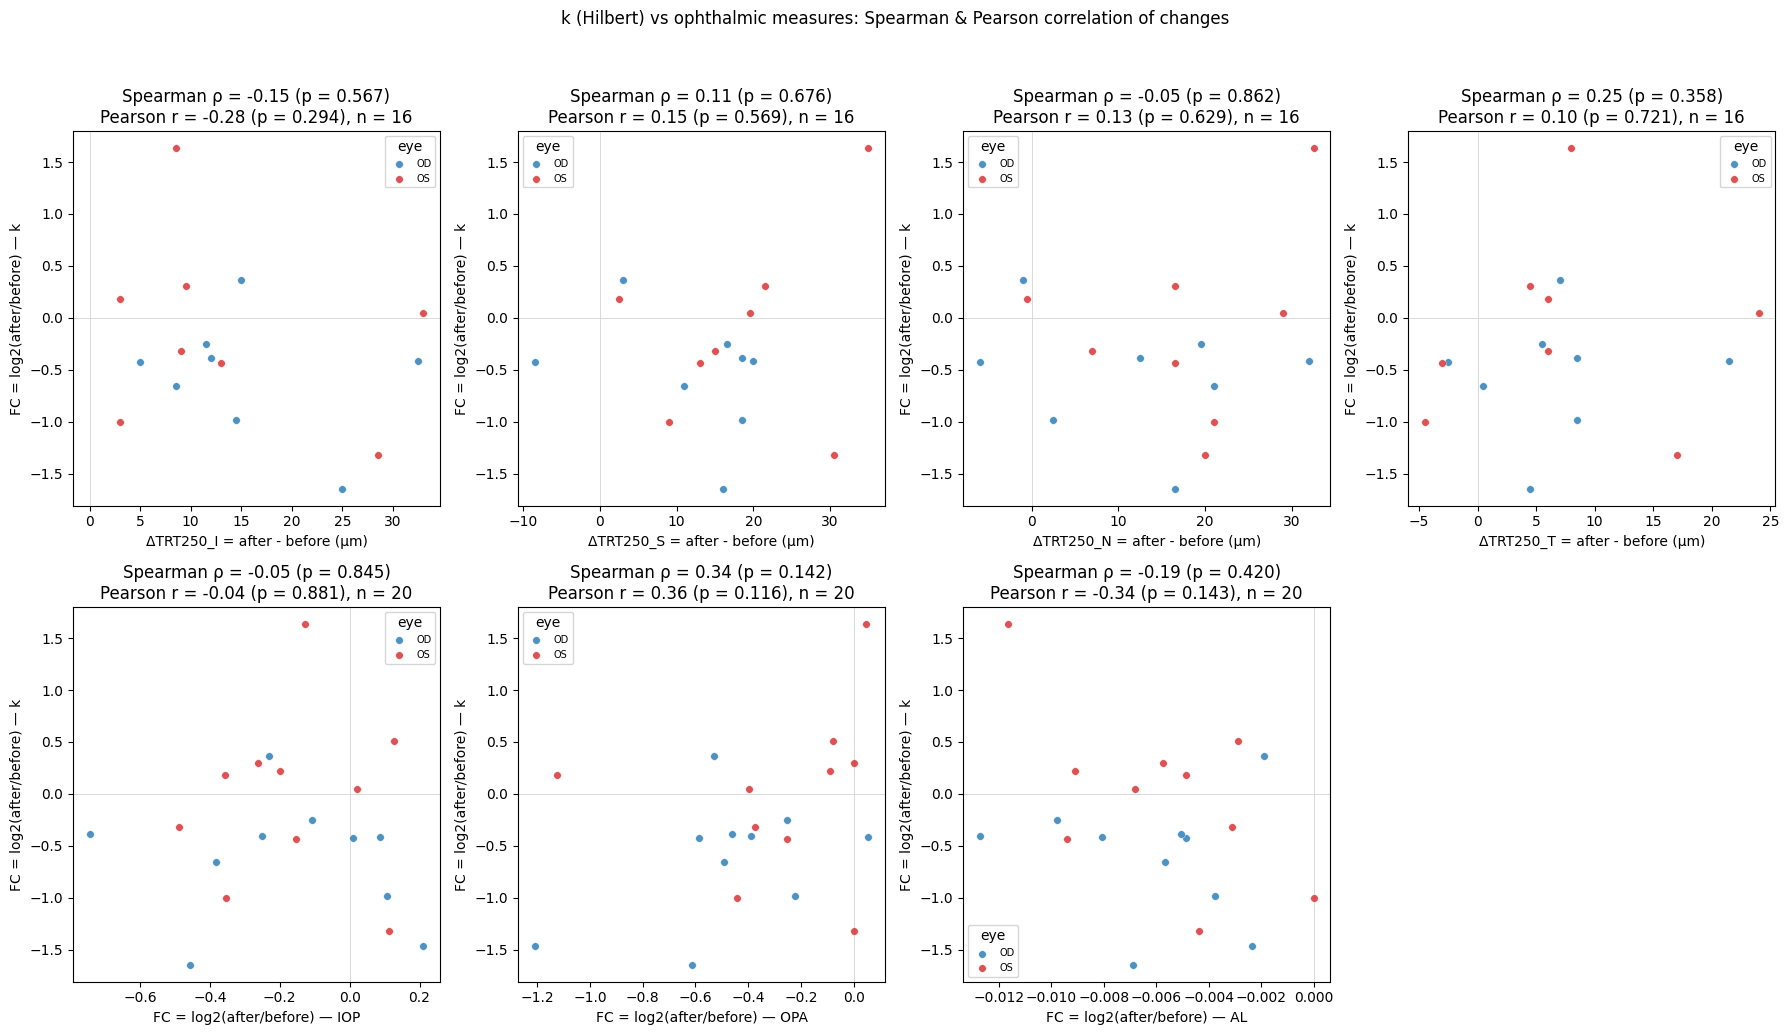

In [11]:
def fold_change(agg, metric):
    """FC = log2(after/before), by (patient_id, eye)."""
    piv = agg.pivot_table(index=["patient_id", "eye"], columns="phase",
                          values=metric, observed=True)
    for c in ["before", "post"]:
        if c not in piv.columns:
            piv[c] = np.nan
    return np.log2(piv["post"] / piv["before"])


def delta_after_before(agg, metric):
    """delta = after - before, by (patient_id, eye)."""
    piv = agg.pivot_table(index=["patient_id", "eye"], columns="phase",
                          values=metric, observed=True)
    for c in ["before", "post"]:
        if c not in piv.columns:
            piv[c] = np.nan
    return piv["post"] - piv["before"]


# TRT250 : delta (after - before, µm) ; IOP/OPA/AL : FC (log2 ratio)
CHANGE_FN = {m: delta_after_before for m in TRT_DESCRIPTIONS}
CHANGE_FN.update({m: fold_change for m in ["IOP", "OPA", "AL"]})


def change_xlabel(metric):
    if metric in TRT_DESCRIPTIONS:
        return f"Δ{metric} = after - before ({UNITS.get(metric, '')})"
    return f"FC = log2(after/before) — {metric}"


fc_k = fold_change(agg, "k")

fig, axes = plt.subplots(2, 4, figsize=(4.5 * 4, 5 * 2))
for ax, metric in zip(axes.ravel(), METRICS_OPHTALMIC):
    change_metric = CHANGE_FN[metric](agg, metric)
    d = pd.concat([fc_k.rename("fc_k"), change_metric.rename("change_metric")], axis=1).dropna()
    eyes = d.index.get_level_values("eye")
    if len(d) >= 3:
        r_s, p_s = spearmanr(d["change_metric"], d["fc_k"])
        r_p, p_p = pearsonr(d["change_metric"], d["fc_k"])
    else:
        r_s = p_s = r_p = p_p = np.nan

    for eye, color in EYE_COLORS.items():
        m = (eyes == eye)
        ax.scatter(d["change_metric"][m], d["fc_k"][m], color=color, s=30, alpha=0.8,
                  edgecolor="white", linewidth=0.4, label=eye)

    ax.axhline(0, color="0.85", lw=0.7, zorder=0)
    ax.axvline(0, color="0.85", lw=0.7, zorder=0)
    ax.set_xlabel(change_xlabel(metric))
    ax.set_ylabel("FC = log2(after/before) — k")
    ax.set_title(f"Spearman ρ = {r_s:.2f} (p = {p_s:.3f})\n"
                 f"Pearson r = {r_p:.2f} (p = {p_p:.3f}), n = {len(d)}")
    ax.legend(title="eye", fontsize=7)

for ax in axes.ravel()[len(METRICS_OPHTALMIC):]:
    ax.axis("off")
fig.suptitle("k (Hilbert) vs ophthalmic measures: Spearman & Pearson correlation of changes", y=1.03)
fig.tight_layout()
plt.show()


# 6. Valeurs avant vol (Hilbert) vs delta TRT250

La valeur *avant vol* de `CT`, `delta_CT` et `k` (méthode de Hilbert)
prédit-elle l'ampleur du changement subséquent de l'épaisseur rétinienne
(`delta TRT250 = après − avant`, µm) ? Une ligne par mesure de Hilbert
(`CT`, `delta_CT`, `k`), une colonne par quadrant `TRT250`
(Inférieur/Supérieur/Nasal/Temporal) ; corrélations de Spearman et de
Pearson en titre.


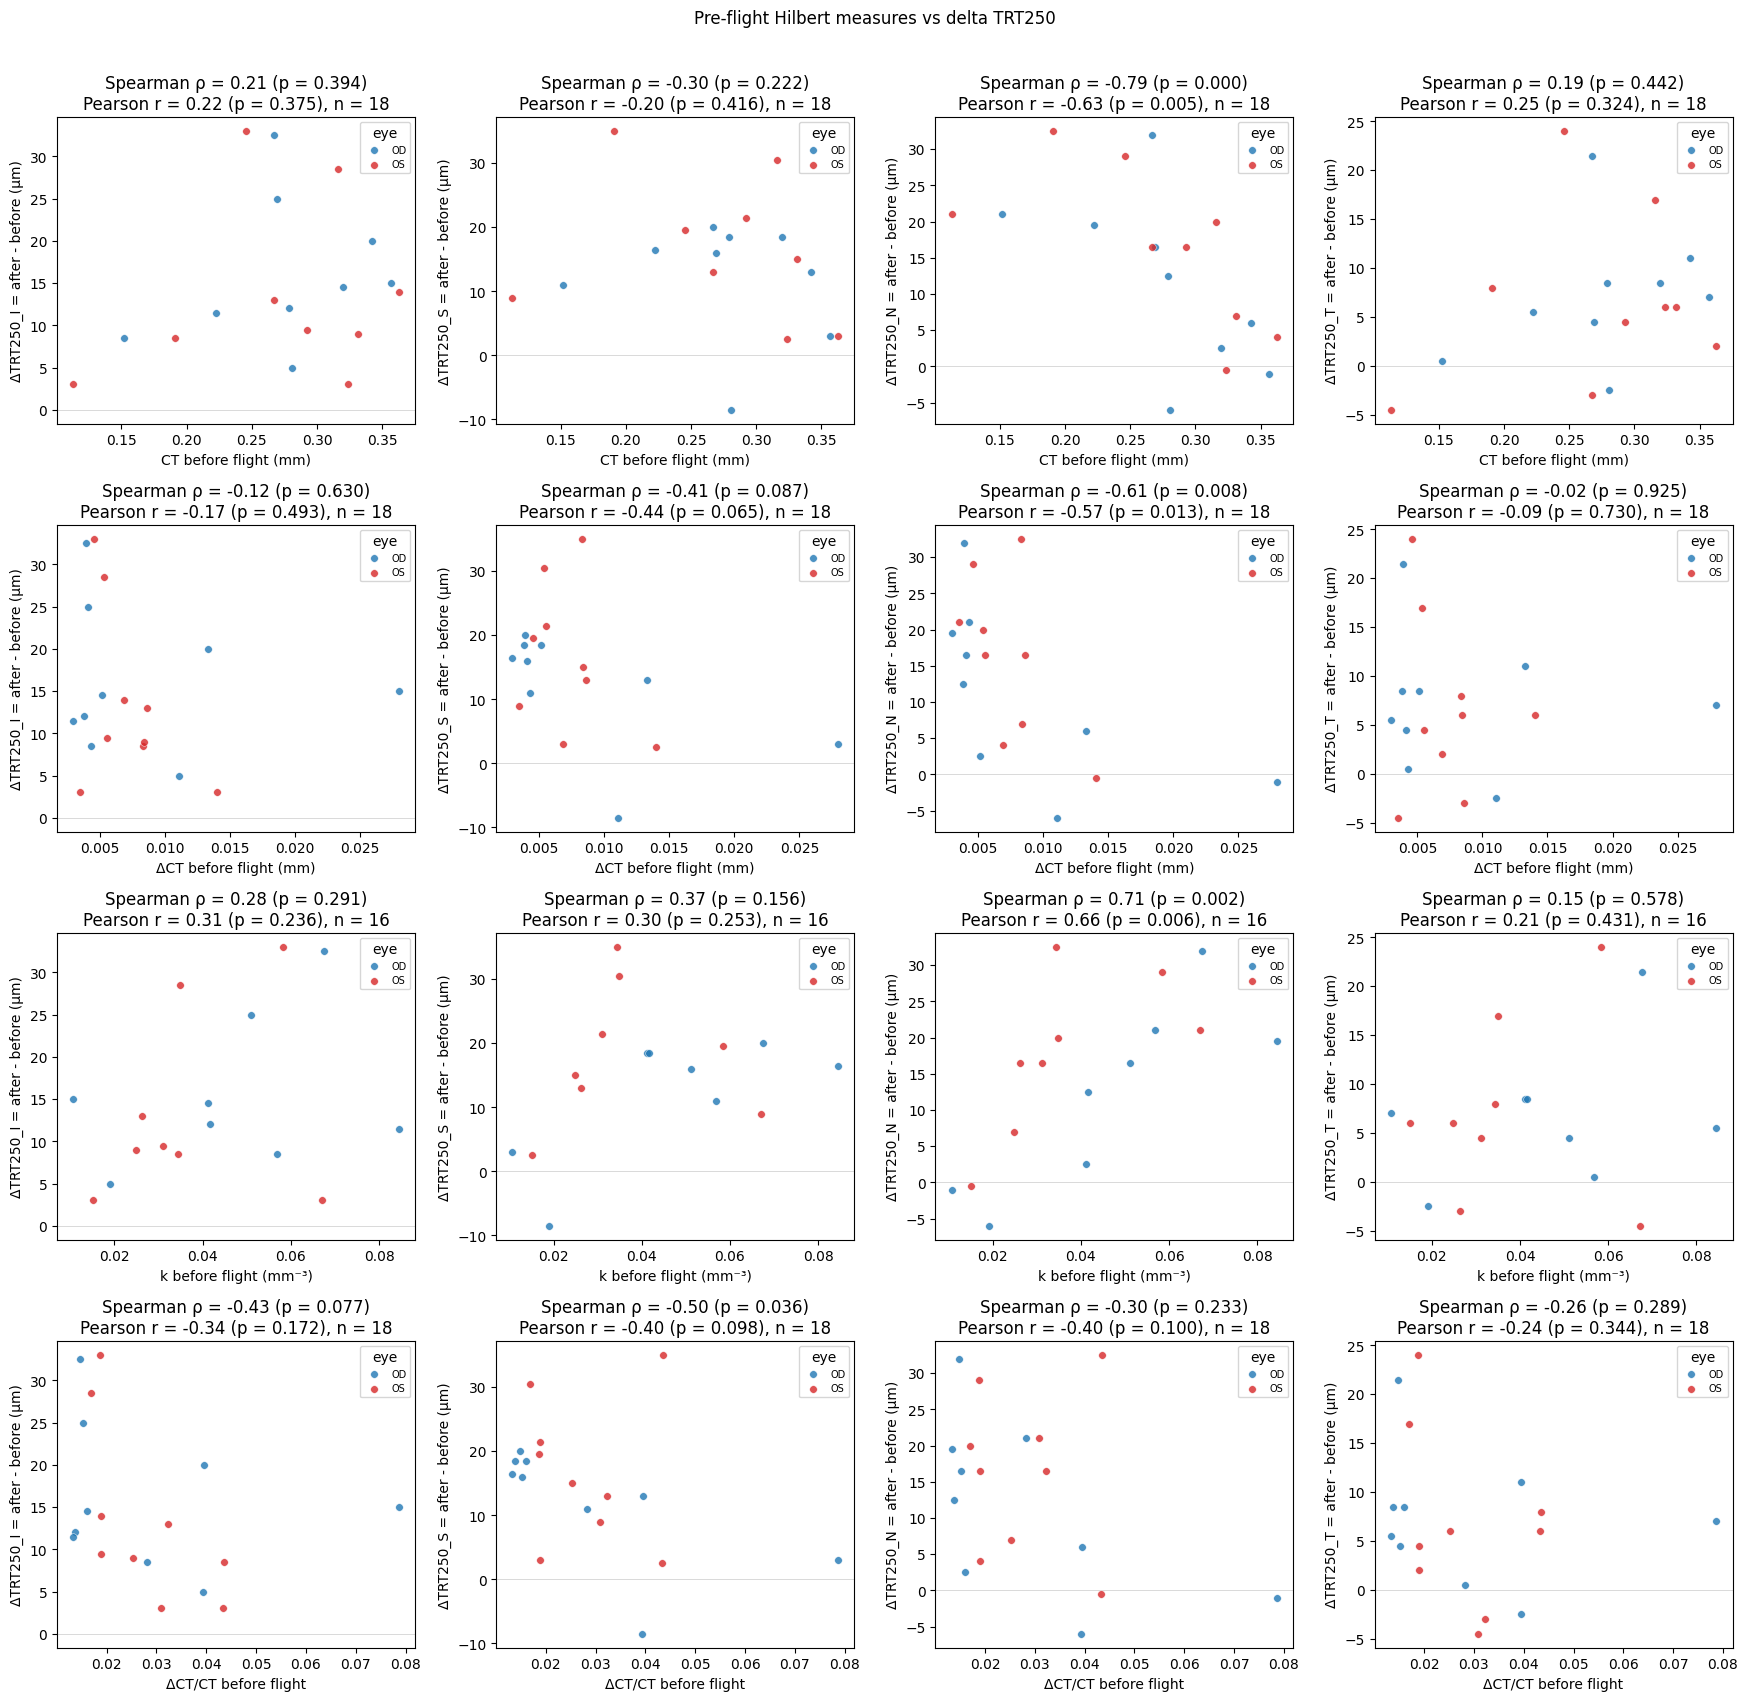

In [12]:
def value_before(agg, metric):
    """Pre-flight ('before') value, by (patient_id, eye)."""
    piv = agg.pivot_table(index=["patient_id", "eye"], columns="phase",
                          values=metric, observed=True)
    if "before" not in piv.columns:
        return pd.Series(np.nan, index=piv.index)
    return piv["before"]


fig, axes = plt.subplots(len(METRICS_RIGIDITY), len(TRT_DESCRIPTIONS),
                          figsize=(4.4 * len(TRT_DESCRIPTIONS), 4.2 * len(METRICS_RIGIDITY)))
for row, metric in zip(axes, METRICS_RIGIDITY):
    before_metric = value_before(agg, metric)
    for ax, trt in zip(row, TRT_DESCRIPTIONS):
        delta_trt = delta_after_before(agg, trt)
        d = pd.concat([before_metric.rename("before_metric"), delta_trt.rename("delta_trt")],
                      axis=1).dropna()
        eyes = d.index.get_level_values("eye")
        if len(d) >= 3:
            r_s, p_s = spearmanr(d["before_metric"], d["delta_trt"])
            r_p, p_p = pearsonr(d["before_metric"], d["delta_trt"])
        else:
            r_s = p_s = r_p = p_p = np.nan

        for eye, color in EYE_COLORS.items():
            m = (eyes == eye)
            ax.scatter(d["before_metric"][m], d["delta_trt"][m], color=color, s=30, alpha=0.8,
                      edgecolor="white", linewidth=0.4, label=eye)

        ax.axhline(0, color="0.85", lw=0.7, zorder=0)
        ax.set_xlabel(f"{pretty(metric)} before flight{unit_suffix(metric)}")
        ax.set_ylabel(f"Δ{trt} = after - before ({UNITS.get(trt, '')})")
        ax.set_title(f"Spearman ρ = {r_s:.2f} (p = {p_s:.3f})\n"
                     f"Pearson r = {r_p:.2f} (p = {p_p:.3f}), n = {len(d)}")
        ax.legend(title="eye", fontsize=7)

fig.suptitle("Pre-flight Hilbert measures vs delta TRT250", y=1.01)
fig.tight_layout()
plt.show()
